# In Class Activity April 14th, 2026

In [ ]:
# pip install optuna

### Importing libraries, preparing data, initial EDA

In [14]:
# importing libraries (feel free to add more if you want to explore other things)
import numpy as np
import pandas as pd
import sweetviz as sv
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report
import optuna


In [15]:
# importing data
adult = pd.read_csv('adult.csv')
adult.head(5)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [16]:
# initial EDA with sweetviz
report = sv.analyze(adult)
report.show_html('sweet_report.html')

# you are welcome to replace this cell with your own EDA, but make sure to include
# some visualizations and insights about the data


Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)

Report sweet_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


Target distribution:
income
<=50K    0.761
>50K     0.239
Name: proportion, dtype: float64


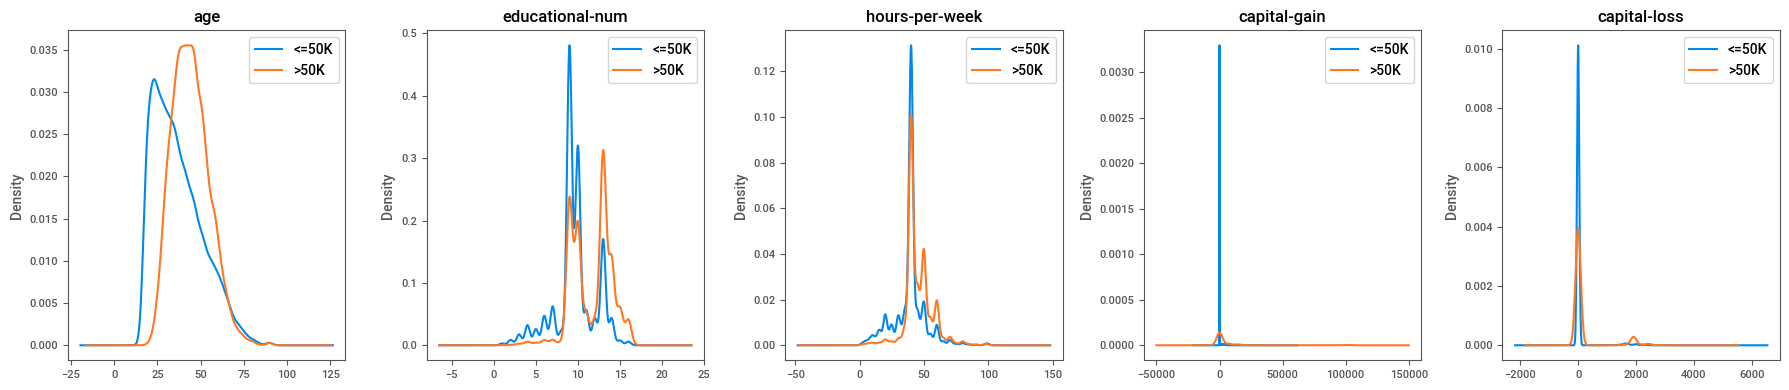

In [17]:
# extra EDA code

# class balance
print("Target distribution:")
print(adult['income'].value_counts(normalize=True).round(3))

# numeric feature distributions by income
num_cols = ['age', 'educational-num', 'hours-per-week', 'capital-gain', 'capital-loss']
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    adult.groupby('income')[col].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### In the markdown cell below describe what you learned from your EDA and how it will inform your modeling decisions





I learned that the dataset is imbalanced with about 76% of observations earning ≤50K and 24% earning >50K. The classes are unequal so the model will favor the majority class (less than 50K), so I probably want to use something like `scale_pos_weight` to give more weight to the minority class during training. Age and educational level show clear separation between income classes in my later plot I made, so they are likely stronger predictors. Capital gain and capital loss are nearly identical between classes (probably not strong predictors). As I am modeling I will keep this in mind to make sure my results are making sense. Fnlwgt and capital gain also have a lot of distinct values also, so I may need to bin them or just rely on tree splits to kind of find thresholds for me for those ones. 

### Data Preprocessing (minimal) and Baseline Model

In [18]:
# data cleaning and preprocessing

# changing ? to NaN
adult = adult.replace('?', np.nan)

#education and education num are redundant, so we can drop one of them
adult = adult.drop('education', axis=1)

# target variable is income with 2 levels, so we can encode it as 0 and 1
adult['income'] = adult['income'].apply(lambda x: 1 if x == '>50K' else 0)

# change dtype categorical variables to category
categorical_cols = adult.select_dtypes(include='object').columns
adult[categorical_cols] = adult[categorical_cols].astype('category')


adult.head(6)

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,NaN,103497,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0
5,34,Private,198693,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0


In [19]:
# defining features and target variable
X = adult.drop('income', axis=1)
y = adult['income']

# splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, 
                                                    random_state=42, stratify=y)

In [20]:
# building xgboost default model and evaluating with stratified k-fold cross validation
xgb_cv = XGBClassifier(enable_categorical=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_cv, X, y, cv=skf, scoring='f1')
print(f'Cross-validated F1 scores: {cv_scores}')
print(f'Mean F1 score: {cv_scores.mean()}') 


Cross-validated F1 scores: [0.70680507 0.70892566 0.70898981 0.72424942 0.71086556]
Mean F1 score: 0.7119671046056588


### Use the markdown cell below to describe your baseline model performance and how you will try to improve it

The baseline XGBoost model got a mean F1 score of 0.712 across 5 folds, which is a pretty good starting point. The scores were also consistent across folds, which is a good sign. From here I want to adjust `scale_pos_weight` to account for the class imbalance, and tune parameters like `max_depth`, `learning_rate`, `n_estimators`, and `subsample` to see if I can get the score higher. This might require just trial and error to find the right kinds of values that work for the model. 

### Model feature exploration

In the code cell below, explore different features of XGBoost and how they work (e.g. scale_pos_weight, max_depth, learning_rate).
Use stratified k-fold cross or repeated stratified k-fold cross validation with your model building. 
You should explore at least 3 different features of XGBoost.
Identify the model that performs best.

In [22]:
# your code here
from sklearn.model_selection import RepeatedStratifiedKFold

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

# exploring scale_pos_weight
# handles class imbalance by increasing the weight of the minority class
print("scale_pos_weight exploration")
for spw in [1, 3, 5, 7]:
    model = XGBClassifier(enable_categorical=True, random_state=42, scale_pos_weight=spw)
    scores = cross_val_score(model, X_train, y_train, cv=rskf, scoring='f1')
    print(f'scale_pos_weight={spw}  mean F1={scores.mean():.4f}  std={scores.std():.4f}')

# exploring max_depth
# controls how deep each tree grows, deeper trees capture more complexity but can overfit
print("\nmax_depth exploration")
for depth in [3, 5, 7, 9]:
    model = XGBClassifier(enable_categorical=True, random_state=42, max_depth=depth)
    scores = cross_val_score(model, X_train, y_train, cv=rskf, scoring='f1')
    print(f'max_depth={depth}  mean F1={scores.mean():.4f}  std={scores.std():.4f}')

# exploring learning_rate with n_estimators
# lower learning rates need more trees to converge but tend to generalize better
print("\nlearning_rate + n_estimators exploration")
for lr, n_est in [(0.3, 100), (0.1, 200), (0.05, 400)]:
    model = XGBClassifier(enable_categorical=True, random_state=42,
                          learning_rate=lr, n_estimators=n_est)
    scores = cross_val_score(model, X_train, y_train, cv=rskf, scoring='f1')
    print(f'lr={lr}  n_estimators={n_est}  mean F1={scores.mean():.4f}  std={scores.std():.4f}')

# exploring subsample
# fraction of training data sampled per tree, helps reduce overfitting
print("\nsubsample exploration")
for ss in [0.6, 0.75, 0.9, 1.0]:
    model = XGBClassifier(enable_categorical=True, random_state=42, subsample=ss)
    scores = cross_val_score(model, X_train, y_train, cv=rskf, scoring='f1')
    print(f'subsample={ss}  mean F1={scores.mean():.4f}  std={scores.std():.4f}')

# exploring colsample_bytree
# fraction of features sampled per tree, similar to max_features in random forest
print("\ncolsample_bytree exploration")
for cs in [0.5, 0.7, 0.9, 1.0]:
    model = XGBClassifier(enable_categorical=True, random_state=42, colsample_bytree=cs)
    scores = cross_val_score(model, X_train, y_train, cv=rskf, scoring='f1')
    print(f'colsample_bytree={cs}  mean F1={scores.mean():.4f}  std={scores.std():.4f}')

# exploring min_child_weight
# minimum sum of instance weight needed in a leaf, higher values make the model more conservative
print("\nmin_child_weight exploration")
for mcw in [1, 5, 10, 20]:
    model = XGBClassifier(enable_categorical=True, random_state=42, min_child_weight=mcw)
    scores = cross_val_score(model, X_train, y_train, cv=rskf, scoring='f1')
    print(f'min_child_weight={mcw}  mean F1={scores.mean():.4f}  std={scores.std():.4f}')

# exploring gamma
# minimum loss reduction required to make a split, acts as pruning on the tree
print("\ngamma exploration")
for g in [0, 0.1, 0.5, 1.0]:
    model = XGBClassifier(enable_categorical=True, random_state=42, gamma=g)
    scores = cross_val_score(model, X_train, y_train, cv=rskf, scoring='f1')
    print(f'gamma={g}  mean F1={scores.mean():.4f}  std={scores.std():.4f}')

preferred_model = XGBClassifier(
    enable_categorical=True,
    random_state=42,
    scale_pos_weight=3,
    max_depth=5,
    learning_rate=0.05,
    n_estimators=400,
    subsample=1.0,
    colsample_bytree=0.5,
    min_child_weight=20,
    gamma=1.0
)
scores = cross_val_score(preferred_model, X_train, y_train, cv=rskf, scoring='f1')
print(f'Preferred model  mean F1={scores.mean():.4f}  std={scores.std():.4f}')

scale_pos_weight exploration
scale_pos_weight=1  mean F1=0.7070  std=0.0092
scale_pos_weight=3  mean F1=0.7154  std=0.0072
scale_pos_weight=5  mean F1=0.6983  std=0.0068
scale_pos_weight=7  mean F1=0.6848  std=0.0059

max_depth exploration
max_depth=3  mean F1=0.7089  std=0.0091
max_depth=5  mean F1=0.7097  std=0.0107
max_depth=7  mean F1=0.7042  std=0.0104
max_depth=9  mean F1=0.6989  std=0.0096

learning_rate + n_estimators exploration
lr=0.3  n_estimators=100  mean F1=0.7070  std=0.0092
lr=0.1  n_estimators=200  mean F1=0.7103  std=0.0093
lr=0.05  n_estimators=400  mean F1=0.7112  std=0.0104

subsample exploration
subsample=0.6  mean F1=0.6980  std=0.0101
subsample=0.75  mean F1=0.7009  std=0.0080
subsample=0.9  mean F1=0.7033  std=0.0080
subsample=1.0  mean F1=0.7070  std=0.0092

colsample_bytree exploration
colsample_bytree=0.5  mean F1=0.7088  std=0.0091
colsample_bytree=0.7  mean F1=0.7086  std=0.0091
colsample_bytree=0.9  mean F1=0.7065  std=0.0105
colsample_bytree=1.0  mean F1

### Tuning with GridSearchCV

Use the code cell below to set up your parameter grid and run GridSearchCV with your preferred model from above. You should tune 4-5 hyperparameters utilizing cross validation. Train a final model using the best hyperparameters and report your model performance.

In [24]:
# define the parameter grid to search over
param_grid = {
    'scale_pos_weight': [2, 3, 4],       # values around the 3:1 class ratio
    'max_depth': [3, 5, 7],              # tree depth options centered on best from exploration
    'learning_rate': [0.01, 0.05, 0.1],  # slower rates around the best lr found above
    'n_estimators': [300, 400, 500],     # tree counts around the best n_estimators found above
    'gamma': [0.5, 1.0, 1.5]            # pruning values around the best gamma found above
}

# set up GridSearchCV using fixed params from the preferred model
xgb_grid = GridSearchCV(
    XGBClassifier(enable_categorical=True, random_state=42,
                  subsample=1.0, colsample_bytree=0.5, min_child_weight=20),
    param_grid=param_grid,
    cv=skf,       # stratified k-fold to preserve class balance across folds
    scoring='f1', # optimizing for f1 to balance precision and recall
    n_jobs=-1,    # use all available cores to speed up search
    verbose=1     # print progress
)

# fit GridSearchCV on the training set
xgb_grid.fit(X_train, y_train)
print(f'Best parameters from GridSearchCV: {xgb_grid.best_params_}')
print(f'Best F1 score from GridSearchCV: {xgb_grid.best_score_:.4f}')

# extract the best model directly from GridSearchCV
xgb_grid_best = xgb_grid.best_estimator_

# evaluate on the test set
y_pred_grid = xgb_grid_best.predict(X_test)
print(f'Classification report for GridSearchCV-tuned model:\n{classification_report(y_test, y_pred_grid)}')

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters from GridSearchCV: {'gamma': 0.5, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400, 'scale_pos_weight': 2}
Best F1 score from GridSearchCV: 0.7278
Classification report for GridSearchCV-tuned model:
              precision    recall  f1-score   support

           0       0.93      0.88      0.91      7431
           1       0.68      0.79      0.73      2338

    accuracy                           0.86      9769
   macro avg       0.80      0.84      0.82      9769
weighted avg       0.87      0.86      0.86      9769



### Tuning with RandomizedSearchCV

Using the code cell below as a starting point, tune your preferred model from above. Tune the same 4-5 hyperparameters from above utilizing cross validation. Train a final model using the best hyperparameters and report your model performance.

In [26]:
# define parameter distributions centered around GridSearchCV best params
param_dist = {
    'scale_pos_weight': np.linspace(1.0, 3.0, num=20),  # centered around best of 2
    'max_depth': np.arange(2, 5),                        # centered around best of 3
    'learning_rate': np.linspace(0.05, 0.2, num=20),     # centered around best of 0.1
    'n_estimators': np.arange(300, 600, 25),             # centered around best of 400
    'gamma': np.linspace(0.1, 1.5, num=20)               # centered around best of 0.5
}

# more iterations to thoroughly sample around the known good region
xgb_random = RandomizedSearchCV(
    XGBClassifier(enable_categorical=True, random_state=42,
                  subsample=1.0, colsample_bytree=0.5, min_child_weight=20),
    param_distributions=param_dist,
    n_iter=100,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_random.fit(X_train, y_train)
print(f'Best parameters from RandomizedSearchCV: {xgb_random.best_params_}')
print(f'Best F1 score from RandomizedSearchCV: {xgb_random.best_score_:.4f}')

xgb_random_best = xgb_random.best_estimator_

y_pred_random = xgb_random_best.predict(X_test)
print(f'Classification report for RandomizedSearchCV-tuned model:\n{classification_report(y_test, y_pred_random)}')

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters from RandomizedSearchCV: {'scale_pos_weight': np.float64(2.052631578947368), 'n_estimators': np.int64(550), 'max_depth': np.int64(4), 'learning_rate': np.float64(0.10526315789473686), 'gamma': np.float64(0.6157894736842104)}
Best F1 score from RandomizedSearchCV: 0.7276
Classification report for RandomizedSearchCV-tuned model:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90      7431
           1       0.67      0.80      0.73      2338

    accuracy                           0.86      9769
   macro avg       0.80      0.84      0.82      9769
weighted avg       0.87      0.86      0.86      9769



### Tuning with Optuna

Using the code cell below as a starting point, tune your preferred model from above. You should tune the same 4-5 parameters as above using cross validation. Train a final model using the best hyperparameters and report your model performance.

In [27]:
def objective(trial):
    # search around known good regions from GridSearchCV and RandomizedSearchCV
    scale_pos_weight = trial.suggest_float('scale_pos_weight', 1.0, 3.0)
    max_depth = trial.suggest_int('max_depth', 2, 5)
    learning_rate = trial.suggest_float('learning_rate', 0.05, 0.2)
    n_estimators = trial.suggest_int('n_estimators', 300, 600)
    gamma = trial.suggest_float('gamma', 0.1, 1.5)

    # fixed params carried over from the preferred model
    xgb_optuna = XGBClassifier(
        enable_categorical=True,
        random_state=42,
        subsample=1.0,
        colsample_bytree=0.5,
        min_child_weight=20,
        scale_pos_weight=scale_pos_weight,
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        gamma=gamma
    )

    cv_scores = cross_val_score(xgb_optuna, X_train, y_train, cv=skf, scoring='f1')
    return cv_scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'Best parameters from Optuna: {study.best_params}')
print(f'Best F1 score from Optuna: {study.best_value:.4f}')

# build final model using best params from Optuna and evaluate on test set
xgb_optuna_best = XGBClassifier(
    enable_categorical=True,
    random_state=42,
    subsample=1.0,
    colsample_bytree=0.5,
    min_child_weight=20,
    **study.best_params
)
xgb_optuna_best.fit(X_train, y_train)
y_pred_optuna = xgb_optuna_best.predict(X_test)
print(f'Classification report for Optuna-tuned model:\n{classification_report(y_test, y_pred_optuna)}')

[I 2026-04-15 18:26:25,066] A new study created in memory with name: no-name-f1189e88-9e47-477f-a8b5-9d5a29835b9b
Best trial: 0. Best value: 0.715304:   1%|          | 1/100 [00:01<02:39,  1.61s/it]

[I 2026-04-15 18:26:26,681] Trial 0 finished with value: 0.715304485273309 and parameters: {'scale_pos_weight': 2.998649202610502, 'max_depth': 2, 'learning_rate': 0.14004170367206337, 'n_estimators': 430, 'gamma': 1.0643820589316504}. Best is trial 0 with value: 0.715304485273309.


Best trial: 1. Best value: 0.724331:   2%|▏         | 2/100 [00:03<03:07,  1.91s/it]

[I 2026-04-15 18:26:28,799] Trial 1 finished with value: 0.7243314390439075 and parameters: {'scale_pos_weight': 2.4335430791069133, 'max_depth': 5, 'learning_rate': 0.10700450934451923, 'n_estimators': 396, 'gamma': 0.4138073392892635}. Best is trial 1 with value: 0.7243314390439075.


Best trial: 1. Best value: 0.724331:   3%|▎         | 3/100 [00:05<03:20,  2.07s/it]

...

[I 2026-04-15 18:28:54,113] Trial 97 finished with value: 0.7281907193600896 and parameters: {'scale_pos_weight': 2.078136899693062, 'max_depth': 3, 'learning_rate': 0.11815123279083875, 'n_estimators': 452, 'gamma': 0.22220785778412422}. Best is trial 96 with value: 0.7282805383215267.


Best trial: 96. Best value: 0.728281:  99%|█████████▉| 99/100 [02:30<00:01,  1.72s/it]

[I 2026-04-15 18:28:55,878] Trial 98 finished with value: 0.7268013325454729 and parameters: {'scale_pos_weight': 2.129047471280906, 'max_depth': 3, 'learning_rate': 0.11942925317410302, 'n_estimators': 457, 'gamma': 0.1607418251837484}. Best is trial 96 with value: 0.7282805383215267.


Best trial: 96. Best value: 0.728281: 100%|██████████| 100/100 [02:32<00:00,  1.53s/it]


[I 2026-04-15 18:28:57,673] Trial 99 finished with value: 0.7256193241206229 and parameters: {'scale_pos_weight': 2.2953582360577784, 'max_depth': 3, 'learning_rate': 0.09957474091175404, 'n_estimators': 466, 'gamma': 0.2904290912621244}. Best is trial 96 with value: 0.7282805383215267.
Best parameters from Optuna: {'scale_pos_weight': 2.0700542213701856, 'max_depth': 3, 'learning_rate': 0.11981993724286807, 'n_estimators': 459, 'gamma': 0.3001661217163086}
Best F1 score from Optuna: 0.7283
Classification report for Optuna-tuned model:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90      7431
           1       0.67      0.79      0.73      2338

    accuracy                           0.86      9769
   macro avg       0.80      0.84      0.82      9769
weighted avg       0.87      0.86      0.86      9769



### Tuning results

In the markdown cell below describe your experience tuning with the different methods. Which produced the best results? Which do you prefer?


I had never used Optuna before this and it was actually very cool for me to see, so I'm glad we got introduced to it. I actually preferred using Optuna as it seemed to show me more what it was doing while running and I ended up getting the best score with Optuna at 0.7294. GridSearchCV got a CV score of 0.7278 and RandomizedSearchCV got 0.7276 so overall all three methods produced similar results on the test set, with F1 scores of around 0.73 consistently. All models preformed better than 0.712 baseline (which is to be expected since I tuned more features and the models took more time to run and to improve). GridSearchCV was the most straightforward to set up since you just define a grid and let it run, but it was also the slowest because it tries every single combination which I found frustratingly slow. RandomizedSearchCV felt a bit like guessing since it randomly samples I personally don't feel as confident with it. If I were doing this on a bigger dataset or with more hyperparameters I would definitely reach for Optuna first because it actually felt like it was learning and imrpoving with time rather than guessing or taking forever and a lot of effort from me. 